# Lorentzian Representation / Compression Error

(a) Fit each `S(\omega)` in the `dipole_polarizability_160Yb` dataset with 2, 3, ..., `N_MAX` Lorentzians and measure reconstruction error using strength-function-only objectives.

Below is a sweep cell given an input `N_MAX`. Results are cached under `tests/cache/yb_lorentzian_compression/`, so increasing `N_MAX` only fits the newly requested values.

## Setup

In [48]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "Dipole_polarizability").exists() and ROOT.name == "tests":
    ROOT = ROOT.parent
if not (ROOT / "Dipole_polarizability").exists():
    raise RuntimeError("Run this notebook from the SMLR repository root or from SMLR/tests.")

sys.path.insert(0, str(ROOT / "Dipole_polarizability" / "src"))
sys.path.insert(0, str(ROOT / "src"))

import helper_gpt  # noqa: E402

plt.rcParams.update({"figure.dpi": 130, "axes.grid": True})
print("Repository root:", ROOT)
print("Using helper:", Path(helper_gpt.__file__).resolve())

Repository root: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR
Using helper: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/Dipole_polarizability/src/helper_gpt.py


## Configuration

In [49]:
# Main control: fit 2, 3, ..., N_MAX Lorentzians.
N_MAX = 30
N_MIN = 2

# Fitting conventions. ETA is the full Lorentzian width used by the existing dipole code.
ETA = 2.0
MIN_SPACING = 0.01
GRID_M = None  # None means use the full omega grid for NNLS initialization.

# Parameter-space subset for this compression test.
FILTER_RANGES = {"p1": [0.4, 1.8], "p2": [1.5, 4.0]}

# Optional extra throttle for quick smoke tests after filtering.
SAMPLE_LIMIT = None
FORCE_REFIT = False

STRENGTH_DIR = ROOT / "dipole_polarizability_160Yb" / "total_strength"
ALPHAD_DIR = ROOT / "dipole_polarizability_160Yb" / "total_alphaD"
CACHE_DIR = ROOT / "tests" / "cache" / "yb_lorentzian_compression"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Strength directory:", STRENGTH_DIR)
print("Cache directory:", CACHE_DIR)

Strength directory: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/dipole_polarizability_160Yb/total_strength
Cache directory: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/tests/cache/yb_lorentzian_compression


## Load Strength Data

In [50]:
dataset = helper_gpt.load_dataset(
    strength_dir=str(STRENGTH_DIR),
    alphaD_dir=str(ALPHAD_DIR),
    strength_regex=r"strength_(?P<p2>[0-9.]+)_(?P<p1>[0-9.]+)\.out",
    filter_ranges=FILTER_RANGES,
)

if SAMPLE_LIMIT is not None:
    keep = np.arange(min(int(SAMPLE_LIMIT), len(dataset.strengths)))
    dataset.strengths = [dataset.strengths[i] for i in keep]
    dataset.sample_ids = [dataset.sample_ids[i] for i in keep]
    dataset.param_values = dataset.param_values[keep]
    dataset.alphaD_values = dataset.alphaD_values[keep]

omega = np.asarray(dataset.strengths[0][:, 0], dtype=np.float32)
for i, strength in enumerate(dataset.strengths[1:], start=1):
    if strength.shape[0] != omega.size or not np.allclose(strength[:, 0], omega):
        raise ValueError(f"Spectrum {i} does not share the common omega grid.")

strength_matrix = np.stack([np.asarray(s[:, 1], dtype=np.float32) for s in dataset.strengths], axis=0)
print(f"Loaded {len(dataset.strengths)} spectra on {omega.size} omega points.")
print("Parameter names:", dataset.param_names)
display(pd.DataFrame(dataset.param_values, columns=dataset.param_names).describe())

Loaded 121 spectra on 400 omega points.
Parameter names: ['p1', 'p2']


,p1,p2
count,121.000000,121.000000
mean,1.100000,2.750000
std,0.408302,0.793857
min,0.457000,1.500000
25%,0.714000,2.000000
50%,1.100000,2.750000
75%,1.486000,3.500000
max,1.743000,4.000000


## Fit And Score Helpers

The fit objective is strength-only. AlphaD below is included only as a derived diagnostic of how the compressed curve changes the inverse-energy moment.

In [51]:
def trapz_weights(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    dx = np.diff(x)
    w = np.empty_like(x)
    w[0] = dx[0] / 2.0
    w[-1] = dx[-1] / 2.0
    w[1:-1] = (x[2:] - x[:-2]) / 2.0
    return w


OMEGA_WEIGHTS = trapz_weights(omega)


def alphaD_from_strength(y: np.ndarray) -> float:
    return float(helper_gpt.ALPHAD_FAC * np.trapz(y / np.maximum(omega, 1e-6), omega))


def score_fit(y: np.ndarray, yhat: np.ndarray) -> dict[str, float]:
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    residual = yhat - y
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    wrmse = float(np.sqrt(np.sum(OMEGA_WEIGHTS * residual ** 2) / np.sum(OMEGA_WEIGHTS)))
    l2_true = float(np.sqrt(np.sum(OMEGA_WEIGHTS * y ** 2)))
    rel_l2 = float(np.sqrt(np.sum(OMEGA_WEIGHTS * residual ** 2)) / max(l2_true, 1e-12))
    denom_var = float(np.sum((y - np.mean(y)) ** 2))
    r2 = float(1.0 - np.sum(residual ** 2) / denom_var) if denom_var > 0 else np.nan
    alphaD_true = alphaD_from_strength(y)
    alphaD_hat = alphaD_from_strength(yhat)
    return {
        "rmse": rmse,
        "weighted_rmse": wrmse,
        "mae": float(np.mean(np.abs(residual))),
        "max_abs": float(np.max(np.abs(residual))),
        "rel_l2": rel_l2,
        "nrmse_peak": float(rmse / max(np.max(np.abs(y)), 1e-12)),
        "nrmse_range": float(rmse / max(np.ptp(y), 1e-12)),
        "r2": r2,
        "alphaD_true_from_strength": alphaD_true,
        "alphaD_hat_from_compressed_strength": alphaD_hat,
        "alphaD_relerr_from_compressed_strength": float(abs(alphaD_hat - alphaD_true) / max(abs(alphaD_true), 1e-12)),
    }


def sample_cache_path(sample_index: int, n_lorentz: int) -> Path:
    sid = "_".join(dataset.sample_ids[sample_index])
    return CACHE_DIR / f"sample{sample_index:03d}_{sid}_n{n_lorentz:02d}_eta{ETA:g}_spacing{MIN_SPACING:g}.npz"


def fit_one(sample_index: int, n_lorentz: int, force: bool = False) -> dict:
    path = sample_cache_path(sample_index, n_lorentz)
    y = strength_matrix[sample_index]
    if path.exists() and not force:
        packed = np.load(path, allow_pickle=False)
        E = packed["E"]
        B = packed["B"]
        yhat = packed["yhat"]
        elapsed = float(packed.get("elapsed_seconds", np.array(np.nan)))
    else:
        start = time.perf_counter()
        E, B, yhat = helper_gpt.fit_strength_with_tf_lorentzian(
            omega,
            y,
            int(n_lorentz),
            float(ETA),
            grid_M=GRID_M,
            min_spacing=float(MIN_SPACING),
        )
        elapsed = time.perf_counter() - start
        np.savez_compressed(path, E=E, B=B, yhat=yhat, elapsed_seconds=np.array(elapsed))

    scores = score_fit(y, yhat)
    return {
        "sample_index": sample_index,
        "n_lorentz": int(n_lorentz),
        "elapsed_seconds": elapsed,
        "p1": float(dataset.param_values[sample_index, 0]),
        "p2": float(dataset.param_values[sample_index, 1]),
        "sample_id": "_".join(dataset.sample_ids[sample_index]),
        **scores,
    }


def run_sweep(n_min: int = N_MIN, n_max: int = N_MAX, force: bool = FORCE_REFIT) -> pd.DataFrame:
    rows = []
    n_values = list(range(int(n_min), int(n_max) + 1))
    total = len(n_values) * len(dataset.strengths)
    count = 0
    start = time.perf_counter()
    for n_lorentz in n_values:
        for sample_index in range(len(dataset.strengths)):
            rows.append(fit_one(sample_index, n_lorentz, force=force))
            count += 1
            if count == 1 or count % 25 == 0 or count == total:
                print(f"{count:4d}/{total} fits scored after {time.perf_counter() - start:7.1f} s", end="\r")
    print()
    df = pd.DataFrame(rows)
    out_csv = CACHE_DIR / f"summary_n{n_min}_to_n{n_max}_eta{ETA:g}_spacing{MIN_SPACING:g}.csv"
    df.to_csv(out_csv, index=False)
    print("Saved summary:", out_csv)
    return df

## Run The Compression Sweep

In [52]:
results = run_sweep()
summary = (
    results.groupby("n_lorentz")
    .agg(
        spectra=("sample_index", "count"),
        rmse_mean=("rmse", "mean"),
        rmse_median=("rmse", "median"),
        rmse_p90=("rmse", lambda x: np.quantile(x, 0.90)),
        rel_l2_mean=("rel_l2", "mean"),
        rel_l2_median=("rel_l2", "median"),
        rel_l2_p90=("rel_l2", lambda x: np.quantile(x, 0.90)),
        nrmse_peak_median=("nrmse_peak", "median"),
        max_abs_p90=("max_abs", lambda x: np.quantile(x, 0.90)),
        r2_median=("r2", "median"),
        alphaD_relerr_median=("alphaD_relerr_from_compressed_strength", "median"),
    )
    .reset_index()
)
display(summary)

/var/folders/jb/056vg5td3x140pfzlhf0s5hr0000gn/T/ipykernel_35019/1902416924.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(helper_gpt.ALPHAD_FAC * np.trapz(y / np.maximum(omega, 1e-6), omega))


3509/3509 fits scored after     1.5 s
Saved summary: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/tests/cache/yb_lorentzian_compression/summary_n2_to_n30_eta2_spacing0.01.csv


,n_lorentz,spectra,rmse_mean,rmse_median,rmse_p90,rel_l2_mean,rel_l2_median,rel_l2_p90,nrmse_peak_median,max_abs_p90,r2_median,alphaD_relerr_median
0,2,121,0.768934,0.758080,0.856899,0.306158,0.316544,0.357724,0.094473,3.636926,0.852207,0.111923
1,3,121,0.332845,0.273144,0.502176,0.134511,0.105110,0.220835,0.031604,1.270371,0.983973,0.027832
2,4,121,0.244624,0.227147,0.347121,0.100142,0.084918,0.165161,0.025265,1.013994,0.989240,0.035571
3,5,121,0.193990,0.193515,0.279328,0.079470,0.071643,0.128401,0.020600,0.890982,0.992743,0.038853
4,6,121,0.161362,0.169702,0.229101,0.065895,0.067913,0.109272,0.019068,0.798887,0.993421,0.039902
5,7,121,0.143190,0.136693,0.199683,0.058307,0.059963,0.086238,0.018037,0.764567,0.994685,0.047409
6,8,121,0.127184,0.107112,0.185851,0.051766,0.041360,0.079650,0.012466,0.706286,0.997557,0.062771
7,9,121,0.114191,0.104671,0.166775,0.046188,0.039186,0.072260,0.011525,0.706640,0.997762,0.069984
8,10,121,0.104901,0.101419,0.134862,0.041986,0.037775,0.064478,0.011242,0.713370,0.997909,0.073791
9,11,121,0.100480,0.098009,0.129875,0.040130,0.036788,0.052574,0.011089,0.713986,0.998028,0.075732


## Error Versus Number Of Lorentzians

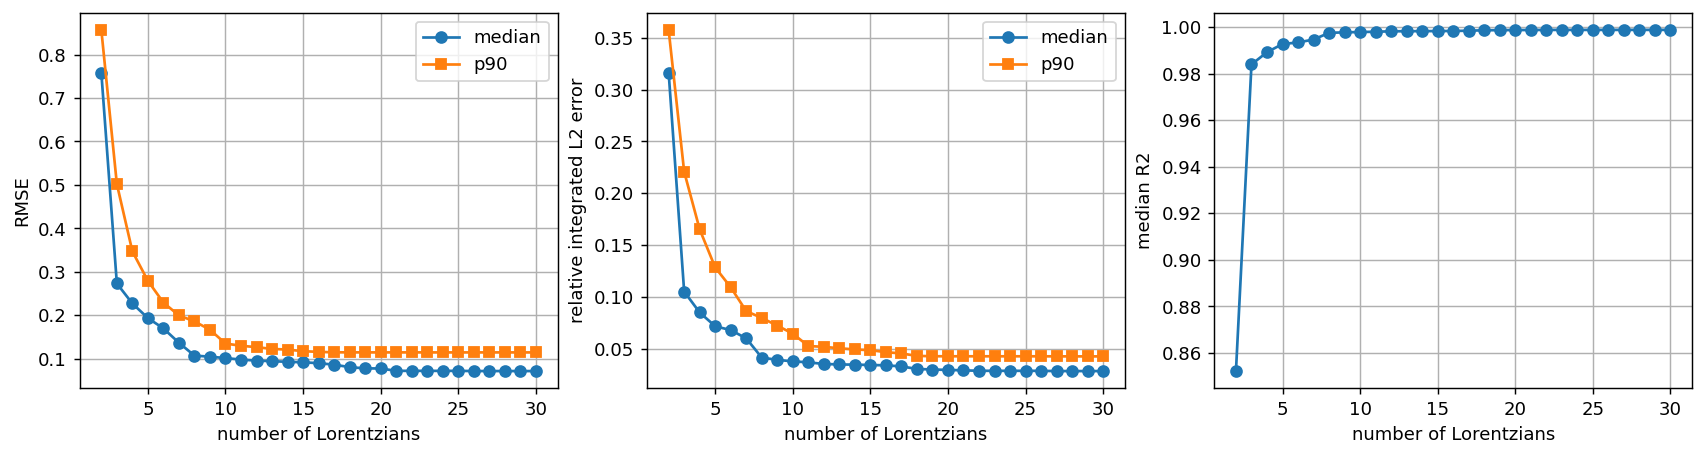

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), constrained_layout=True)

axes[0].plot(summary["n_lorentz"], summary["rmse_median"], marker="o", label="median")
axes[0].plot(summary["n_lorentz"], summary["rmse_p90"], marker="s", label="p90")
axes[0].set_xlabel("number of Lorentzians")
axes[0].set_ylabel("RMSE")
axes[0].legend()

axes[1].plot(summary["n_lorentz"], summary["rel_l2_median"], marker="o", label="median")
axes[1].plot(summary["n_lorentz"], summary["rel_l2_p90"], marker="s", label="p90")
axes[1].set_xlabel("number of Lorentzians")
axes[1].set_ylabel("relative integrated L2 error")
axes[1].legend()

axes[2].plot(summary["n_lorentz"], summary["r2_median"], marker="o")
axes[2].set_xlabel("number of Lorentzians")
axes[2].set_ylabel("median R2")

plt.show()

## Distribution And Worst Cases

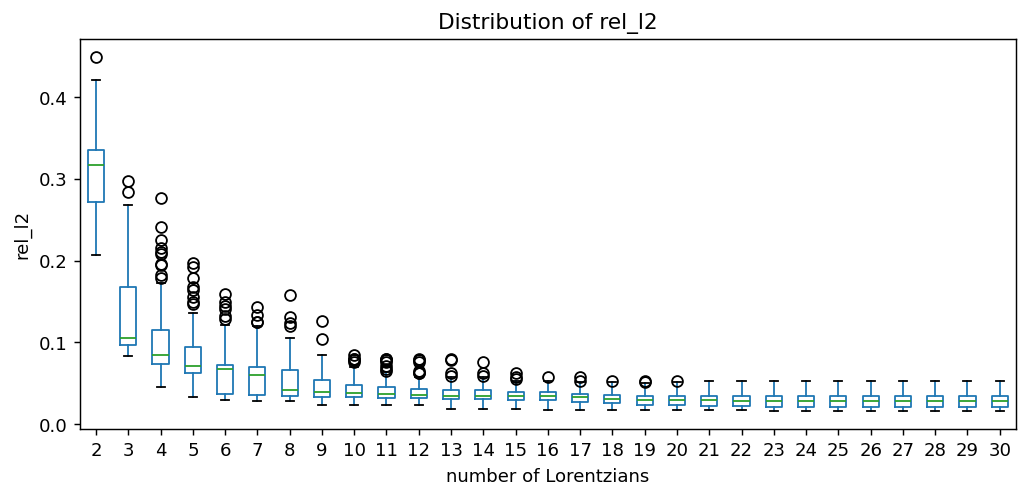

,n_lorentz,sample_index,sample_id,p1,p2,rmse,rel_l2,nrmse_peak,r2
110,2,110,0.4570_4.0000,0.457,4.00,0.825623,0.448932,0.184287,0.619000
99,2,99,0.4570_3.7500,0.457,3.75,0.798920,0.420602,0.173844,0.679195
111,2,111,0.5860_4.0000,0.586,4.00,0.784359,0.413475,0.171516,0.694911
88,2,88,0.4570_3.5000,0.457,3.50,0.771421,0.392329,0.154417,0.731261
100,2,100,0.5860_3.7500,0.586,3.75,0.761251,0.388554,0.151954,0.738980
...,...,...,...,...,...,...,...,...,...
3486,30,98,1.7430_3.5000,1.743,3.50,0.137024,0.052720,0.013934,0.996036
3497,30,109,1.7430_3.7500,1.743,3.75,0.130115,0.051233,0.013667,0.996228
3475,30,87,1.7430_3.2500,1.743,3.25,0.133809,0.050268,0.013344,0.996424
3474,30,86,1.6140_3.2500,1.614,3.25,0.129962,0.049735,0.013301,0.996481


In [54]:
metric = "rel_l2"

fig, ax = plt.subplots(figsize=(9, 4))
results.boxplot(column=metric, by="n_lorentz", ax=ax, grid=False)
ax.set_title(f"Distribution of {metric}")
ax.set_xlabel("number of Lorentzians")
ax.set_ylabel(metric)
fig.suptitle("")
plt.show()

display(
    results.sort_values(["n_lorentz", metric], ascending=[True, False])
    .groupby("n_lorentz")
    .head(5)[["n_lorentz", "sample_index", "sample_id", "p1", "p2", "rmse", "rel_l2", "nrmse_peak", "r2"]]
)

## Inspect A Spectrum Fit

ipywidgets unavailable; using static plot instead: No module named 'ipywidgets'


/var/folders/jb/056vg5td3x140pfzlhf0s5hr0000gn/T/ipykernel_35019/1902416924.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(helper_gpt.ALPHAD_FAC * np.trapz(y / np.maximum(omega, 1e-6), omega))


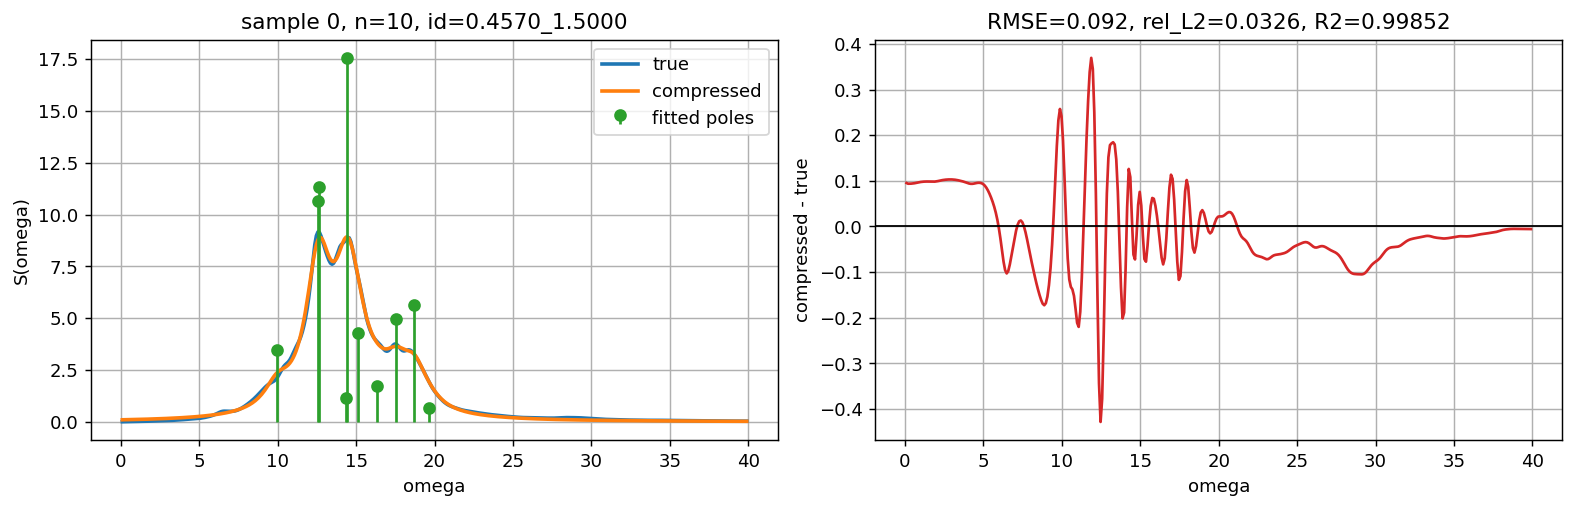

,E,B
0,9.970637,3.466151
1,12.599908,10.661633
2,12.617861,11.327479
3,14.350701,1.146892
4,14.448393,17.554850
5,15.112482,4.295965
6,16.333118,1.741180
7,17.552504,4.960153
8,18.721563,5.622112
9,19.647732,0.651612


In [55]:
def load_fit_arrays(sample_index: int, n_lorentz: int):
    fit_one(sample_index, n_lorentz, force=False)
    packed = np.load(sample_cache_path(sample_index, n_lorentz), allow_pickle=False)
    return packed["E"], packed["B"], packed["yhat"]


def plot_fit(sample_index: int = 0, n_lorentz: int = N_MAX):
    E, B, yhat = load_fit_arrays(int(sample_index), int(n_lorentz))
    y = strength_matrix[int(sample_index)]
    row = fit_one(int(sample_index), int(n_lorentz), force=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
    axes[0].plot(omega, y, label="true", lw=2)
    axes[0].plot(omega, yhat, label="compressed", lw=2)
    axes[0].stem(E, B, linefmt="C2-", markerfmt="C2o", basefmt=" ", label="fitted poles")
    axes[0].set_xlabel("omega")
    axes[0].set_ylabel("S(omega)")
    axes[0].set_title(f"sample {sample_index}, n={n_lorentz}, id={row['sample_id']}")
    axes[0].legend()

    axes[1].plot(omega, yhat - y, color="C3")
    axes[1].axhline(0.0, color="black", lw=1)
    axes[1].set_xlabel("omega")
    axes[1].set_ylabel("compressed - true")
    axes[1].set_title(f"RMSE={row['rmse']:.4g}, rel_L2={row['rel_l2']:.4g}, R2={row['r2']:.5f}")
    plt.show()

    display(pd.DataFrame({"E": E, "B": B}))


try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    worst_at_n = results.loc[results.groupby("n_lorentz")["rel_l2"].idxmax()].set_index("n_lorentz")
    n_slider = widgets.IntSlider(value=N_MAX, min=N_MIN, max=N_MAX, step=1, description="n")
    sample_slider = widgets.IntSlider(value=0, min=0, max=len(dataset.strengths) - 1, step=1, description="sample")
    worst_button = widgets.Button(description="Use worst sample")
    out = widgets.Output()

    def refresh(*_):
        with out:
            clear_output(wait=True)
            plot_fit(sample_slider.value, n_slider.value)

    def use_worst(_):
        sample_slider.value = int(worst_at_n.loc[n_slider.value, "sample_index"])

    n_slider.observe(refresh, names="value")
    sample_slider.observe(refresh, names="value")
    worst_button.on_click(use_worst)
    display(widgets.HBox([n_slider, sample_slider, worst_button]), out)
    refresh()
except Exception as exc:
    print("ipywidgets unavailable; using static plot instead:", exc)
    plot_fit(sample_index=0, n_lorentz=10)

## Acceptance Threshold Helper

Set the thresholds to match what you consider acceptable compression. This reports the first `n` where both the median and p90 satisfy the thresholds.

In [56]:
REL_L2_MEDIAN_THRESHOLD = 0.05
REL_L2_P90_THRESHOLD = 0.10

acceptable = summary[
    (summary["rel_l2_median"] <= REL_L2_MEDIAN_THRESHOLD)
    & (summary["rel_l2_p90"] <= REL_L2_P90_THRESHOLD)
]

if len(acceptable):
    best_n = int(acceptable.iloc[0]["n_lorentz"])
    print(f"First acceptable n: {best_n}")
else:
    print("No n in this sweep met the current thresholds.")

display(summary[["n_lorentz", "rel_l2_median", "rel_l2_p90", "rmse_median", "rmse_p90", "r2_median"]])

First acceptable n: 8


,n_lorentz,rel_l2_median,rel_l2_p90,rmse_median,rmse_p90,r2_median
0,2,0.316544,0.357724,0.758080,0.856899,0.852207
1,3,0.105110,0.220835,0.273144,0.502176,0.983973
2,4,0.084918,0.165161,0.227147,0.347121,0.989240
3,5,0.071643,0.128401,0.193515,0.279328,0.992743
4,6,0.067913,0.109272,0.169702,0.229101,0.993421
5,7,0.059963,0.086238,0.136693,0.199683,0.994685
6,8,0.041360,0.079650,0.107112,0.185851,0.997557
7,9,0.039186,0.072260,0.104671,0.166775,0.997762
8,10,0.037775,0.064478,0.101419,0.134862,0.997909
9,11,0.036788,0.052574,0.098009,0.129875,0.998028


In [57]:
# Placeholder intentionally left empty.

## Optimal Independent-Fit Coordinates For n=8

The compression sweep already fits each spectrum independently for each `n_lorentz`. This section reads the cached `n=8` fits and builds the reduced-coordinate table `(E_1, ..., E_n, B_1, ..., B_n)` for every EDF point. If any `n=8` cache entry is missing, `fit_one(...)` computes just that missing spectrum.

In [58]:
OPT_COORD_N = 8

# In this filename convention, p2 is the first number in strength_<p2>_<p1>.out.
# Set this to "p1" if your local EDF naming says b_TV is p1 instead.
B_TV_PARAM = "p2"
OTHER_PARAM = next(name for name in dataset.param_names if name != B_TV_PARAM)


def load_optimal_coordinate_tables(n_lorentz: int = OPT_COORD_N):
    wide_rows = []
    long_rows = []

    for sample_index in range(len(dataset.strengths)):
        # Reuses compression-sweep cache. Computes only if this exact n/sample is absent.
        fit_one(sample_index, n_lorentz, force=False)
        packed = np.load(sample_cache_path(sample_index, n_lorentz), allow_pickle=False)
        E = np.asarray(packed["E"], dtype=float)
        B = np.asarray(packed["B"], dtype=float)

        wide = {
            "sample_index": sample_index,
            "sample_id": "_".join(dataset.sample_ids[sample_index]),
        }
        for j, name in enumerate(dataset.param_names):
            wide[name] = float(dataset.param_values[sample_index, j])
        for mode in range(n_lorentz):
            wide[f"E_{mode + 1}"] = float(E[mode])
            wide[f"B_{mode + 1}"] = float(B[mode])
            long = {
                "sample_index": sample_index,
                "sample_id": wide["sample_id"],
                "mode": mode + 1,
                "E": float(E[mode]),
                "B": float(B[mode]),
            }
            for j, name in enumerate(dataset.param_names):
                long[name] = float(dataset.param_values[sample_index, j])
            long_rows.append(long)
        wide_rows.append(wide)

    wide_df = pd.DataFrame(wide_rows)
    long_df = pd.DataFrame(long_rows)
    wide_path = CACHE_DIR / f"optimal_coordinates_wide_n{n_lorentz}.csv"
    long_path = CACHE_DIR / f"optimal_coordinates_long_n{n_lorentz}.csv"
    wide_df.to_csv(wide_path, index=False)
    long_df.to_csv(long_path, index=False)
    print("Saved:", wide_path)
    print("Saved:", long_path)
    return wide_df, long_df


optimal_coords_wide, optimal_coords_long = load_optimal_coordinate_tables(OPT_COORD_N)
display(optimal_coords_wide.head())

Saved: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/tests/cache/yb_lorentzian_compression/optimal_coordinates_wide_n8.csv
Saved: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/tests/cache/yb_lorentzian_compression/optimal_coordinates_long_n8.csv


/var/folders/jb/056vg5td3x140pfzlhf0s5hr0000gn/T/ipykernel_35019/1902416924.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(helper_gpt.ALPHAD_FAC * np.trapz(y / np.maximum(omega, 1e-6), omega))


,sample_index,sample_id,p1,p2,E_1,B_1,E_2,B_2,E_3,B_3,E_4,B_4,E_5,B_5,E_6,B_6,E_7,B_7,E_8,B_8
0,0,0.4570_1.5000,0.457,1.5,9.975587,3.475170,12.605093,7.136621,12.616828,14.948970,14.488689,20.733973,15.616558,3.279482,17.425808,5.181712,18.661701,5.769576,19.541061,0.891578
1,1,0.5860_1.5000,0.586,1.5,10.041882,3.470851,12.583774,21.615761,12.599783,1.587477,14.476452,21.668571,15.418287,1.572154,16.401075,1.441404,17.690796,5.488610,18.849430,5.301454
2,2,0.7140_1.5000,0.714,1.5,10.083114,3.529259,12.515124,6.670761,12.531766,17.338503,14.408571,5.702178,14.445356,17.242573,16.031105,1.679173,17.689922,5.597837,18.802372,5.121401
3,3,0.8430_1.5000,0.843,1.5,10.127428,3.638228,12.469010,24.663784,14.329662,3.515845,14.361017,19.558512,15.734921,1.526154,17.579288,4.651762,18.569511,5.615088,19.904558,0.532512
4,4,0.9710_1.5000,0.971,1.5,10.164865,3.807762,12.399788,17.773560,12.420731,7.430601,14.265563,23.032589,15.516623,1.753152,17.613567,4.877915,18.535278,1.687100,18.647635,3.954000


In [ ]:
try:
    import ipywidgets as widgets
    HAVE_WIDGETS = True
except ModuleNotFoundError:
    widgets = None
    HAVE_WIDGETS = False
    print("ipywidgets is not installed; showing static central-point plots instead of clickable grids.")
from IPython.display import clear_output

D_TV_PARAM = next(name for name in dataset.param_names if name != B_TV_PARAM)
EDF_LABEL = {
    D_TV_PARAM: f"d_TV ({D_TV_PARAM})",
    B_TV_PARAM: f"b_TV ({B_TV_PARAM})",
}


def central_value(values):
    values = np.array(sorted(np.unique(values)), dtype=float)
    return float(values[len(values) // 2])


def selected_sample_index(d_value: float, b_value: float) -> int:
    mask = np.isclose(optimal_coords_wide[D_TV_PARAM], d_value) & np.isclose(optimal_coords_wide[B_TV_PARAM], b_value)
    matches = optimal_coords_wide.loc[mask, "sample_index"].to_numpy()
    if len(matches) != 1:
        raise ValueError(f"Expected one sample at d_TV={d_value}, b_TV={b_value}; found {len(matches)}")
    return int(matches[0])


def make_parameter_grid(on_select, selected=None):
    d_values = np.array(sorted(optimal_coords_wide[D_TV_PARAM].unique()), dtype=float)
    b_values = np.array(sorted(optimal_coords_wide[B_TV_PARAM].unique(), reverse=True), dtype=float)
    buttons = []
    for b_value in b_values:
        for d_value in d_values:
            exists = len(optimal_coords_wide[np.isclose(optimal_coords_wide[D_TV_PARAM], d_value) & np.isclose(optimal_coords_wide[B_TV_PARAM], b_value)]) > 0
            is_selected = selected is not None and np.isclose(d_value, selected[0]) and np.isclose(b_value, selected[1])
            button = widgets.Button(
                description="o",
                tooltip=f"{EDF_LABEL[D_TV_PARAM]}={d_value:.4g}, {EDF_LABEL[B_TV_PARAM]}={b_value:.4g}",
                disabled=not exists,
                layout=widgets.Layout(width="26px", height="26px", padding="0px", margin="1px"),
            )
            button.style.button_color = "#1f77b4" if is_selected else ("#f2f2f2" if exists else "#ffffff")
            if exists:
                button.on_click(lambda _button, d=d_value, b=b_value: on_select(float(d), float(b)))
            buttons.append(button)
    grid = widgets.GridBox(
        buttons,
        layout=widgets.Layout(
            grid_template_columns=f"repeat({len(d_values)}, 28px)",
            grid_gap="1px",
            align_items="center",
        ),
    )
    label = widgets.HTML(
        f"<b>Click EDF point</b><br>{EDF_LABEL[D_TV_PARAM]} across columns<br>{EDF_LABEL[B_TV_PARAM]} across rows"
    )
    return widgets.VBox([label, grid])


def plot_selected_spectrum(ax, d_value: float, b_value: float):
    sample_index = selected_sample_index(d_value, b_value)
    E, B, yhat = load_fit_arrays(sample_index, OPT_COORD_N)
    y = strength_matrix[sample_index]
    ax.plot(omega, y, lw=2, label="true")
    ax.plot(omega, yhat, lw=2, label="optimal fit")
    ax.stem(E, B, linefmt="C2-", markerfmt="C2o", basefmt=" ", label="E_i, B_i")
    ax.set_xlabel("omega")
    ax.set_ylabel("S(omega), B_i")
    ax.set_title(f"Fitted spectrum at {EDF_LABEL[D_TV_PARAM]}={d_value:.4g}, {EDF_LABEL[B_TV_PARAM]}={b_value:.4g}")
    ax.legend(fontsize=8)


def plot_coordinate_scan(ax, quantity: str, scan_param: str, fixed_param: str, fixed_value: float, selected_scan_value: float):
    sub = optimal_coords_long[np.isclose(optimal_coords_long[fixed_param], fixed_value)]
    cmap = plt.get_cmap("tab10")
    for mode in sorted(sub["mode"].unique()):
        m = sub[sub["mode"] == mode].sort_values(scan_param)
        ax.plot(m[scan_param], m[quantity], marker="o", lw=1.2, ms=3.5, color=cmap((mode - 1) % 10), label=f"m{mode}")
    ax.axvline(selected_scan_value, color="0.25", ls="--", lw=1)
    ax.set_xlabel(EDF_LABEL[scan_param])
    ax.set_ylabel(quantity)
    ax.set_title(f"{quantity}_i vs {EDF_LABEL[scan_param]}, fixed {EDF_LABEL[fixed_param]}={fixed_value:.4g}")


def show_static_btv_scan(initial_d=None, initial_b=None):
    d_value = central_value(optimal_coords_wide[D_TV_PARAM]) if initial_d is None else float(initial_d)
    b_value = central_value(optimal_coords_wide[B_TV_PARAM]) if initial_b is None else float(initial_b)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)
    plot_selected_spectrum(axes[0], d_value, b_value)
    plot_coordinate_scan(axes[1], "E", B_TV_PARAM, D_TV_PARAM, d_value, b_value)
    plot_coordinate_scan(axes[2], "B", B_TV_PARAM, D_TV_PARAM, d_value, b_value)
    axes[1].legend(ncol=4, fontsize=8)
    fig.suptitle(f"Optimal coordinates scanning b_TV, fixed {EDF_LABEL[D_TV_PARAM]}={d_value:.4g}", y=1.05)
    plt.show()


def show_btv_scan_widget(initial_d=None, initial_b=None):
    initial_d = central_value(optimal_coords_wide[D_TV_PARAM]) if initial_d is None else float(initial_d)
    initial_b = central_value(optimal_coords_wide[B_TV_PARAM]) if initial_b is None else float(initial_b)
    grid_out = widgets.Output()
    detail_out = widgets.Output()

    def render(d_value: float, b_value: float):
        with grid_out:
            clear_output(wait=True)
            display(make_parameter_grid(render, selected=(d_value, b_value)))
        with detail_out:
            clear_output(wait=True)
            fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)
            plot_selected_spectrum(axes[0], d_value, b_value)
            plot_coordinate_scan(axes[1], "E", B_TV_PARAM, D_TV_PARAM, d_value, b_value)
            plot_coordinate_scan(axes[2], "B", B_TV_PARAM, D_TV_PARAM, d_value, b_value)
            axes[1].legend(ncol=4, fontsize=8)
            fig.suptitle(f"Optimal coordinates scanning b_TV, fixed {EDF_LABEL[D_TV_PARAM]}={d_value:.4g}", y=1.05)
            plt.show()

    display(widgets.HBox([grid_out, detail_out], layout=widgets.Layout(align_items="flex-start")))
    render(initial_d, initial_b)


if HAVE_WIDGETS:
    show_btv_scan_widget()
else:
    show_static_btv_scan()

In [34]:
def show_static_dtv_scan(initial_d=None, initial_b=None):
    d_value = central_value(optimal_coords_wide[D_TV_PARAM]) if initial_d is None else float(initial_d)
    b_value = central_value(optimal_coords_wide[B_TV_PARAM]) if initial_b is None else float(initial_b)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)
    plot_selected_spectrum(axes[0], d_value, b_value)
    plot_coordinate_scan(axes[1], "E", D_TV_PARAM, B_TV_PARAM, b_value, d_value)
    plot_coordinate_scan(axes[2], "B", D_TV_PARAM, B_TV_PARAM, b_value, d_value)
    axes[1].legend(ncol=4, fontsize=8)
    fig.suptitle(f"Optimal coordinates scanning d_TV, fixed {EDF_LABEL[B_TV_PARAM]}={b_value:.4g}", y=1.05)
    plt.show()


def show_dtv_scan_widget(initial_d=None, initial_b=None):
    initial_d = central_value(optimal_coords_wide[D_TV_PARAM]) if initial_d is None else float(initial_d)
    initial_b = central_value(optimal_coords_wide[B_TV_PARAM]) if initial_b is None else float(initial_b)
    grid_out = widgets.Output()
    detail_out = widgets.Output()

    def render(d_value: float, b_value: float):
        with grid_out:
            clear_output(wait=True)
            display(make_parameter_grid(render, selected=(d_value, b_value)))
        with detail_out:
            clear_output(wait=True)
            fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)
            plot_selected_spectrum(axes[0], d_value, b_value)
            plot_coordinate_scan(axes[1], "E", D_TV_PARAM, B_TV_PARAM, b_value, d_value)
            plot_coordinate_scan(axes[2], "B", D_TV_PARAM, B_TV_PARAM, b_value, d_value)
            axes[1].legend(ncol=4, fontsize=8)
            fig.suptitle(f"Optimal coordinates scanning d_TV, fixed {EDF_LABEL[B_TV_PARAM]}={b_value:.4g}", y=1.05)
            plt.show()

    display(widgets.HBox([grid_out, detail_out], layout=widgets.Layout(align_items="flex-start")))
    render(initial_d, initial_b)


if HAVE_WIDGETS:
    show_dtv_scan_widget()
else:
    show_static_dtv_scan()

NameError: name 'D_TV_PARAM' is not defined

# Ignore below!!!

## Step b: Train An n=8 Emulator And Track `(E_i, B_i)` Continuity

This section trains the existing Yb emulator on the filtered dataset loaded above. Here `EMULATOR_N = 8` and `EMULATOR_RETAIN = 1.0`, so all eight eigenmodes are retained and tracked as Lorentzian coordinates. Modes are indexed by sorted eigenvalue at each EDF point; no branch matching or continuity enforcement is applied yet, so level crossings and abrupt jumps should remain visible.

In [15]:
import tensorflow as tf

EMULATOR_N = 8
EMULATOR_RETAIN = 1.0
EMULATOR_FOLD = 2.0
EMULATOR_ANSATZ = "paper_dipole"
EMULATOR_WIDTH_MODEL = "affine"

EMULATOR_W_STRENGTH = 100.0
EMULATOR_W_ALPHA_D = 200.0
EMULATOR_W_M1 = 0.0
EMULATOR_M1_TARGET = 875.0

EMULATOR_LEARNING_RATE = 1e-2
EMULATOR_NUM_ITER = 20_000
EMULATOR_PRINT_EVERY = 1_000
EMULATOR_SEED = 1234
FORCE_EMULATOR_RETRAIN = False

EMULATOR_DIR = ROOT / "tests" / "cache" / "yb_emulator_n8_continuity"
EMULATOR_DIR.mkdir(parents=True, exist_ok=True)

emulator_config = helper_gpt.AnsatzConfig(
    n=EMULATOR_N,
    n_params=int(dataset.param_values.shape[1]),
    ansatz=EMULATOR_ANSATZ,
    width_model=EMULATOR_WIDTH_MODEL,
    use_vector_terms=True,
)
print("Emulator config:", helper_gpt.summarize_config(emulator_config))
print("Training spectra:", len(dataset.strengths))
print("Output directory:", EMULATOR_DIR)

Emulator config: {'n': 8, 'n_params': 2, 'ansatz': 'paper_dipole', 'width_model': 'affine', 'use_vector_terms': True, 'n_basis': 3, 'n_upper': 36, 'n_trainable': 145}
Training spectra: 121
Output directory: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/tests/cache/yb_emulator_n8_continuity


Loaded cached emulator parameters: /Users/laurenjin/Documents/projects/SMLR-tests/SMLR/tests/cache/yb_emulator_n8_continuity/best_params_n8.txt


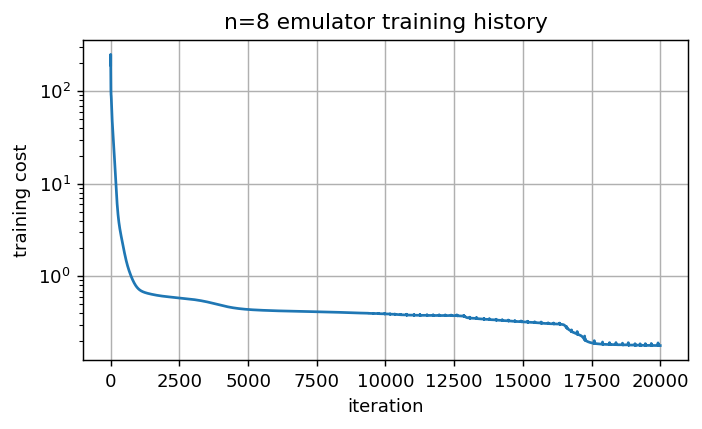

In [16]:
def make_emulator_initial_guess(config, seed: int) -> np.ndarray:
    central_idx = int(np.argmin(np.sum((dataset.param_values - dataset.central_point[None, :]) ** 2, axis=1)))
    central_strength = dataset.strengths[central_idx]
    omega0 = central_strength[:, 0].astype(np.float32)
    y0 = central_strength[:, 1].astype(np.float32)
    keep = max(1, round(EMULATOR_RETAIN * config.n))
    E_hat, B_hat, _ = helper_gpt.fit_strength_with_tf_lorentzian(
        omega0,
        y0,
        keep,
        EMULATOR_FOLD,
        min_spacing=0.01,
    )

    if config.ansatz == "paper_dipole":
        rng = np.random.default_rng(seed)
        init = rng.uniform(0.0, 1.0, size=helper_gpt.count_trainable_parameters(config)).astype(np.float32)
        init[0] = np.float32(EMULATOR_FOLD)
        layout = helper_gpt.get_packed_layout(config)
        init[layout.width_bias_slice] = np.array([1.0], dtype=np.float32)
        init[layout.width_linear_slice] = np.ones(layout.width_linear_slice.stop - layout.width_linear_slice.start, dtype=np.float32)
        init[layout.feature_param_slice] = np.ones(layout.feature_param_slice.stop - layout.feature_param_slice.start, dtype=np.float32)
    else:
        init = helper_gpt.make_random_initial_guess(config, seed=seed, fold=EMULATOR_FOLD)

    return helper_gpt.encode_initial_guess(init, E_hat, B_hat, config, EMULATOR_RETAIN, reference_point=dataset.central_point)


def train_or_load_emulator(config):
    params_path = EMULATOR_DIR / "best_params_n8.txt"
    history_path = EMULATOR_DIR / "cost_history_n8.txt"
    meta_path = EMULATOR_DIR / "training_meta_n8.json"

    if params_path.exists() and not FORCE_EMULATOR_RETRAIN:
        params_np = np.loadtxt(params_path).astype(np.float32)
        history = np.loadtxt(history_path).tolist() if history_path.exists() else []
        print("Loaded cached emulator parameters:", params_path)
        return params_np, history

    np.random.seed(EMULATOR_SEED)
    tf.random.set_seed(EMULATOR_SEED)

    init = make_emulator_initial_guess(config, EMULATOR_SEED)
    params = tf.Variable(init, dtype=tf.float32)
    optimizer = tf.keras.optimizers.Adam(learning_rate=EMULATOR_LEARNING_RATE)
    param_values_tf = tf.convert_to_tensor(dataset.param_values, dtype=tf.float32)
    central_point_tf = tf.convert_to_tensor(dataset.central_point, dtype=tf.float32)

    @tf.function
    def optimization_step():
        with tf.GradientTape() as tape:
            out = helper_gpt.cost_function_batched_generic(
                params=params,
                config=config,
                param_values=param_values_tf,
                strength_true=dataset.strengths,
                alphaD_true=dataset.alphaD_values,
                central_point=central_point_tf,
                retain=EMULATOR_RETAIN,
                w_strength=EMULATOR_W_STRENGTH,
                w_mminus1=EMULATOR_W_ALPHA_D,
                w_mplus1=EMULATOR_W_M1,
                m1_target=EMULATOR_M1_TARGET,
                eps=1e-8,
            )
        grads = tape.gradient(out[0], [params])
        optimizer.apply_gradients(zip(grads, [params]))
        return out

    best_cost = np.inf
    best_iter = -1
    best_params = None
    history = []

    for i in range(int(EMULATOR_NUM_ITER)):
        cost, strength_cost, alphaD_cost, m1_cost, *_ = optimization_step()
        cost_value = float(cost.numpy())
        history.append(cost_value)
        if cost_value < best_cost:
            best_cost = cost_value
            best_iter = i
            best_params = params.numpy().copy()

        if i == 0 or (i + 1) % EMULATOR_PRINT_EVERY == 0:
            print(
                f"iter {i + 1:6d} | cost={cost_value:.6e} | "
                f"strength={float(strength_cost.numpy()):.3e} | "
                f"alphaD={float(alphaD_cost.numpy()):.3e} | "
                f"best={best_cost:.6e} @ {best_iter}"
            )

    np.savetxt(params_path, best_params)
    np.savetxt(history_path, np.asarray(history))
    with open(meta_path, "w") as f:
        json.dump(
            {
                "n": EMULATOR_N,
                "retain": EMULATOR_RETAIN,
                "seed": EMULATOR_SEED,
                "num_iter": EMULATOR_NUM_ITER,
                "best_cost": best_cost,
                "best_iter": best_iter,
                "filter_ranges": FILTER_RANGES,
                "config": helper_gpt.summarize_config(config),
            },
            f,
            indent=2,
        )
    print("Saved emulator parameters:", params_path)
    return best_params, history


emulator_params, emulator_cost_history = train_or_load_emulator(emulator_config)

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(emulator_cost_history)
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("training cost")
ax.set_title("n=8 emulator training history")
plt.show()

In [17]:
def extract_emulator_outputs(params_np: np.ndarray, config):
    params_tf = tf.convert_to_tensor(params_np, dtype=tf.float32)
    param_values_tf = tf.convert_to_tensor(dataset.param_values, dtype=tf.float32)
    central_point_tf = tf.convert_to_tensor(dataset.central_point, dtype=tf.float32)

    M_batch, v_batch, fwhm_batch, _ = helper_gpt.build_model_matrices_and_vectors(
        params_tf,
        config,
        param_values_tf,
        central_point_tf,
    )
    eigenvalues, eigenvectors = tf.linalg.eigh(M_batch)
    eigvecs_t = tf.transpose(eigenvectors, [0, 2, 1])

    n_i = tf.shape(eigenvalues)[1]
    k_keep = tf.cast(tf.round(tf.cast(EMULATOR_RETAIN, tf.float32) * tf.cast(n_i, tf.float32)), tf.int32)
    k_keep = tf.clip_by_value(k_keep, 1, n_i)
    left = (n_i - k_keep) // 2
    right = left + k_keep

    E = eigenvalues[:, left:right]
    eigvecs_t = eigvecs_t[:, left:right, :]
    proj = tf.matmul(eigvecs_t, v_batch[:, :, None])
    B = tf.square(tf.squeeze(proj, axis=-1))

    omega_tf = tf.convert_to_tensor(omega[None, :], dtype=tf.float32)
    yhat = helper_gpt.give_me_Lorentzian_batched(omega_tf, E, B, 0.5 * fwhm_batch).numpy()
    positive_mask = tf.cast(E > 1.0, tf.float32)
    alphaD_pred = tf.reduce_sum((B * positive_mask) / tf.maximum(E, 1e-6), axis=1).numpy() * helper_gpt.ALPHAD_FAC

    E_np = E.numpy()
    B_np = B.numpy()
    rows = []
    for sample_index, params_row in enumerate(dataset.param_values):
        for mode in range(E_np.shape[1]):
            row = {
                "sample_index": sample_index,
                "mode": mode,
                "E": float(E_np[sample_index, mode]),
                "B": float(B_np[sample_index, mode]),
                "fwhm": float(fwhm_batch.numpy()[sample_index]),
                "sample_id": "_".join(dataset.sample_ids[sample_index]),
            }
            for j, name in enumerate(dataset.param_names):
                row[name] = float(params_row[j])
            rows.append(row)
    mode_df = pd.DataFrame(rows)

    metric_rows = []
    for i, y_pred in enumerate(yhat):
        scores = score_fit(strength_matrix[i], y_pred)
        metric_rows.append(
            {
                "sample_index": i,
                "sample_id": "_".join(dataset.sample_ids[i]),
                "alphaD_true": float(dataset.alphaD_values[i]),
                "alphaD_pred": float(alphaD_pred[i]),
                "alphaD_relerr_emulator": float(abs(alphaD_pred[i] - dataset.alphaD_values[i]) / max(abs(dataset.alphaD_values[i]), 1e-12)),
                **{name: float(dataset.param_values[i, j]) for j, name in enumerate(dataset.param_names)},
                **scores,
            }
        )
    metrics_df = pd.DataFrame(metric_rows)
    return mode_df, metrics_df, yhat


mode_df, emulator_metrics_df, emulator_strength_pred = extract_emulator_outputs(emulator_params, emulator_config)
mode_df.to_csv(EMULATOR_DIR / "mode_coordinates_E_B.csv", index=False)
emulator_metrics_df.to_csv(EMULATOR_DIR / "emulator_reconstruction_metrics.csv", index=False)

metric_summary = emulator_metrics_df.agg(
    {
        "rmse": ["mean", "median", lambda x: np.quantile(x, 0.90)],
        "rel_l2": ["mean", "median", lambda x: np.quantile(x, 0.90)],
        "alphaD_relerr_emulator": ["mean", "median", lambda x: np.quantile(x, 0.90)],
        "r2": ["mean", "median"],
    }
)
metric_summary.index = ["mean", "median", "p90"][: len(metric_summary.index)] if len(metric_summary.index) == 3 else metric_summary.index
display(metric_summary)
display(mode_df.head())

/var/folders/jb/056vg5td3x140pfzlhf0s5hr0000gn/T/ipykernel_35019/1902416924.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(helper_gpt.ALPHAD_FAC * np.trapz(y / np.maximum(omega, 1e-6), omega))


,rmse,rel_l2,alphaD_relerr_emulator,r2
mean,0.109503,0.044097,0.001821,0.996809
median,0.108946,0.040613,0.001366,0.997671
p90,0.126468,0.058296,0.004178,NaN


,sample_index,mode,E,B,fwhm,sample_id,p1,p2
0,0,0,9.688231,2.610548,2.225598,0.4570_1.5000,0.457,1.5
1,0,1,11.185000,0.038822,2.225598,0.4570_1.5000,0.457,1.5
2,0,2,12.624769,22.909828,2.225598,0.4570_1.5000,0.457,1.5
3,0,3,14.584725,22.532318,2.225598,0.4570_1.5000,0.457,1.5
4,0,4,16.418789,2.434751,2.225598,0.4570_1.5000,0.457,1.5


### Individual EDF-Parameter Views

Each panel fixes the mode index after eigenvalue sorting. Discontinuities, mode swaps, or sharp bends are the phenomena we want to diagnose before adding neighbor regularization.

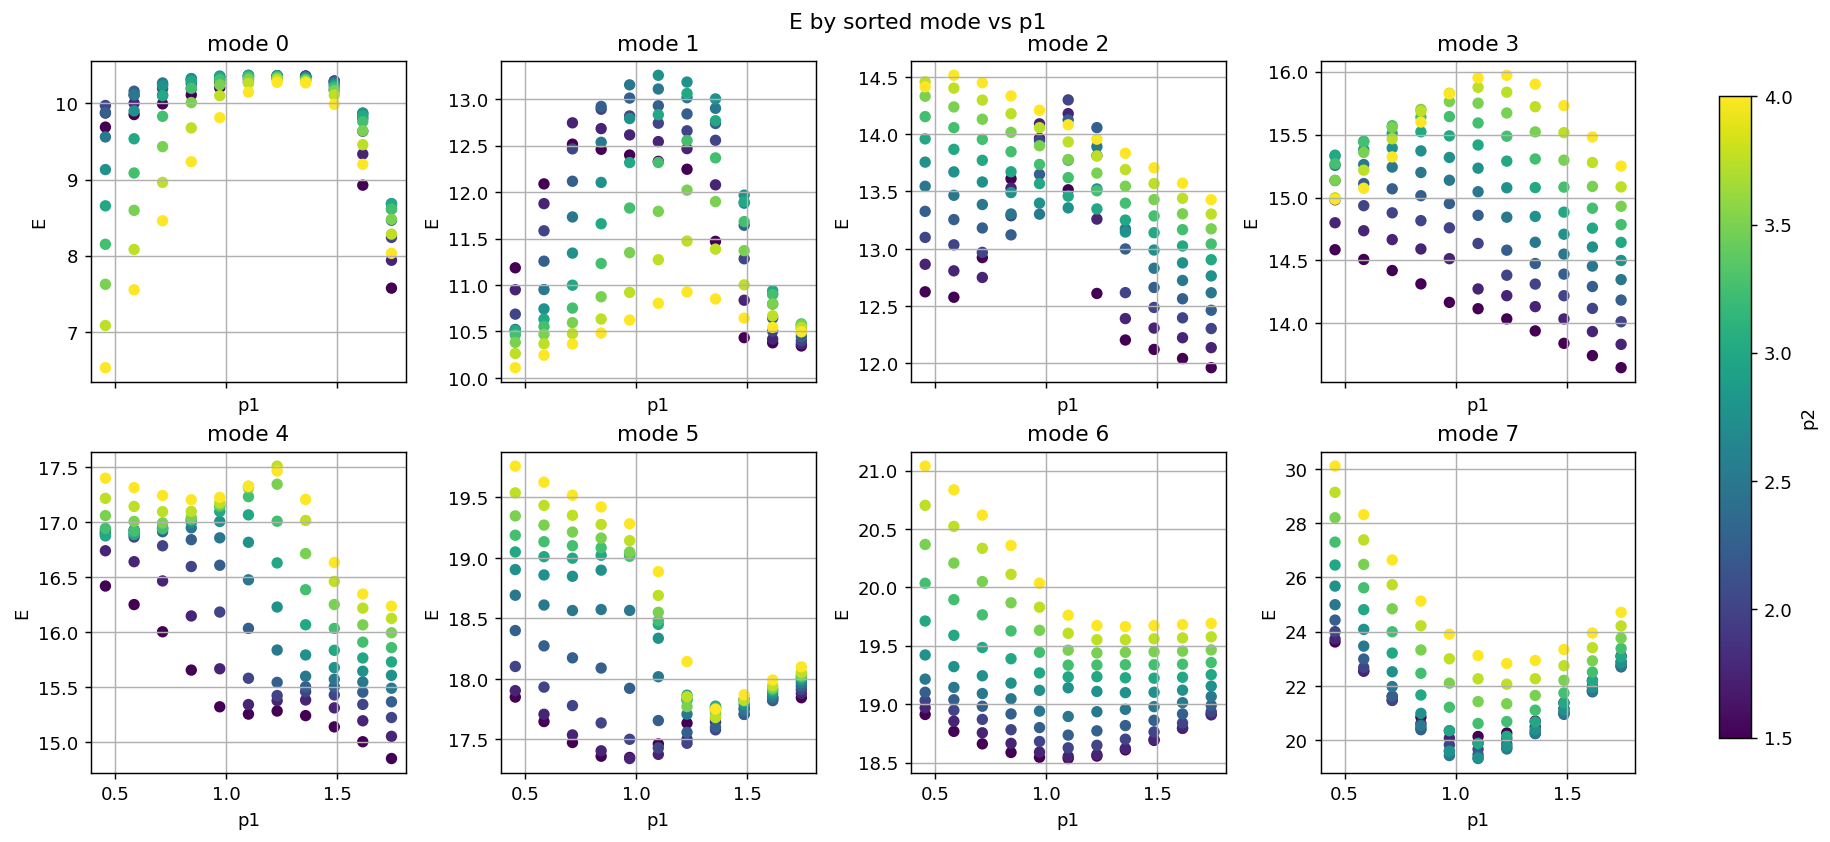

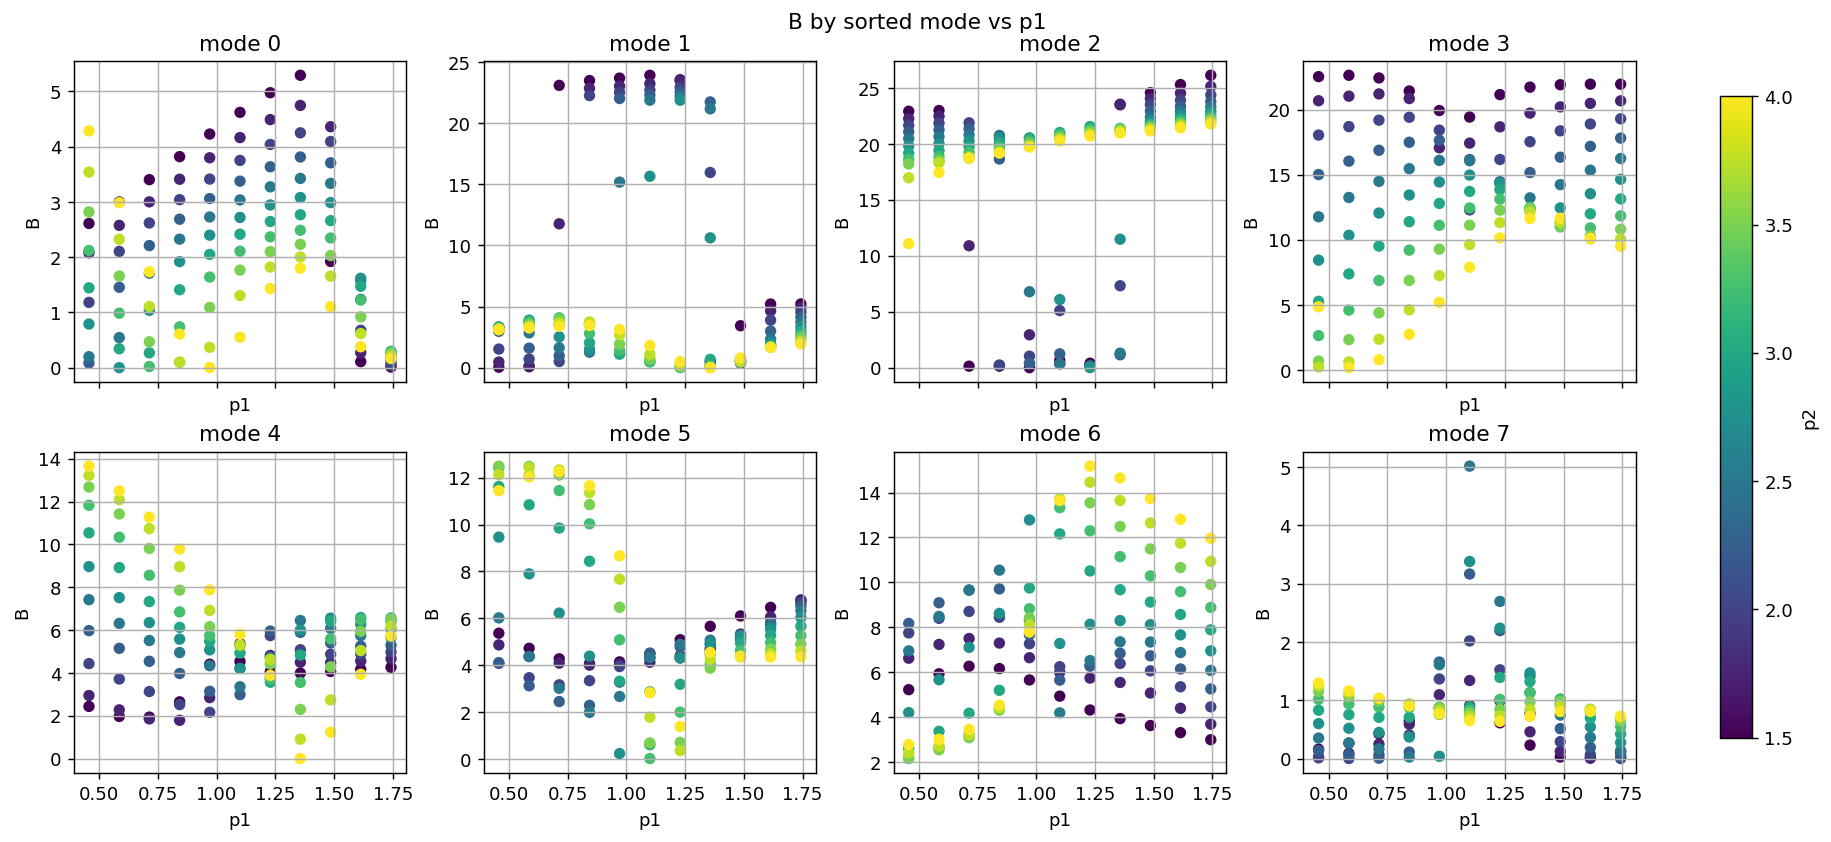

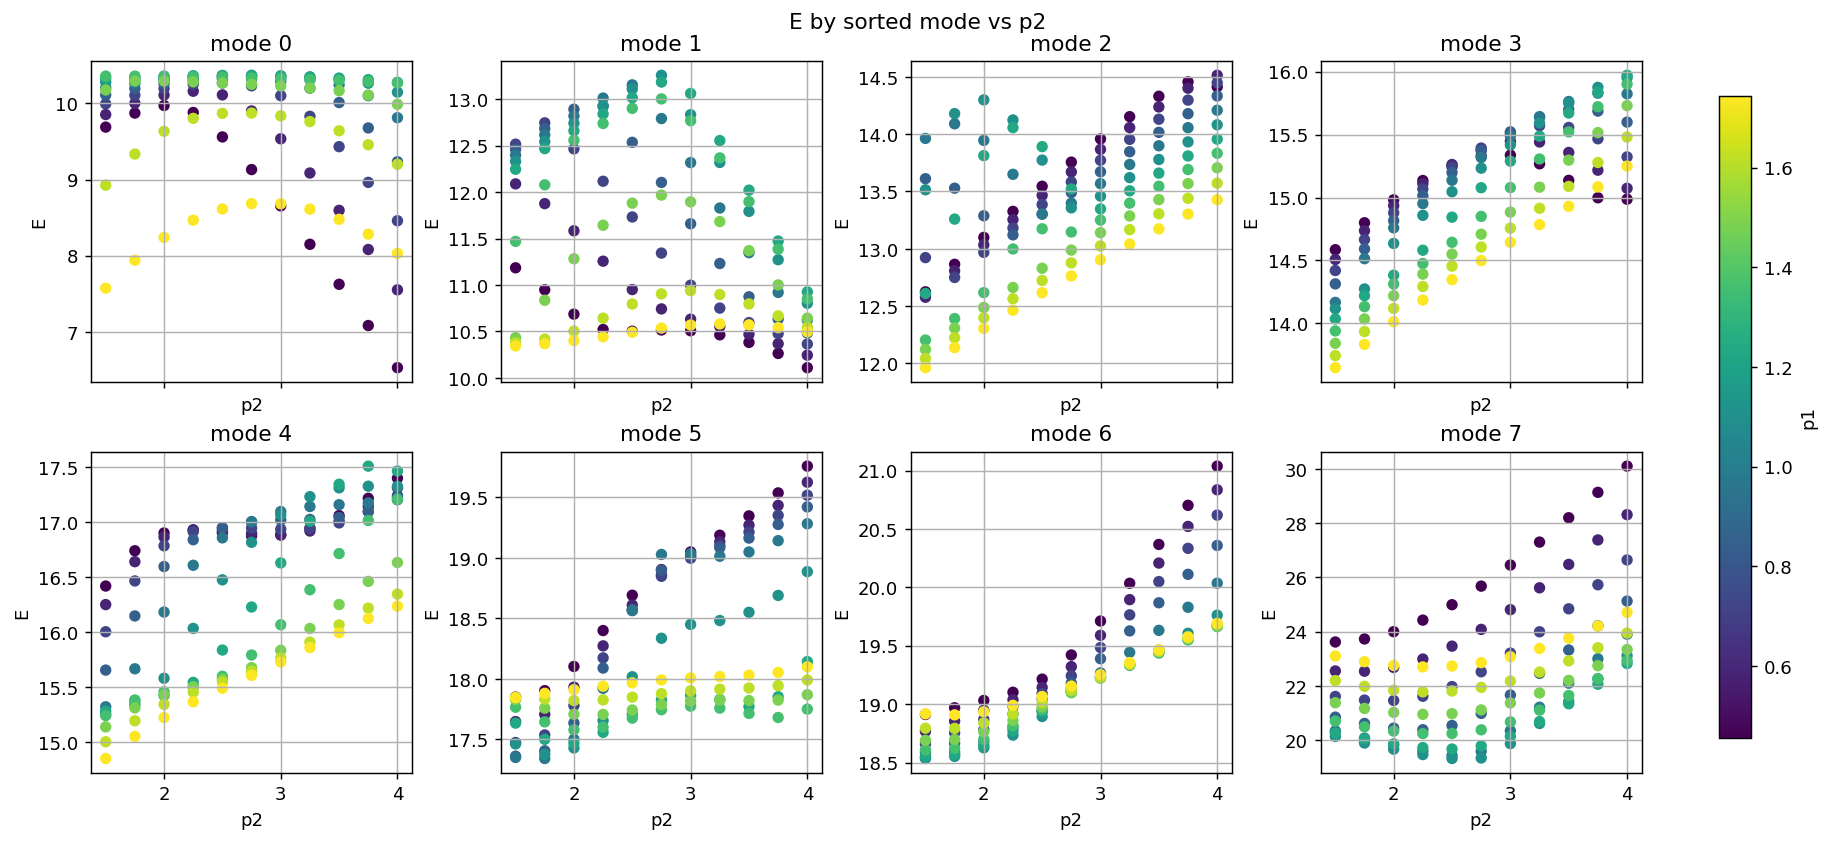

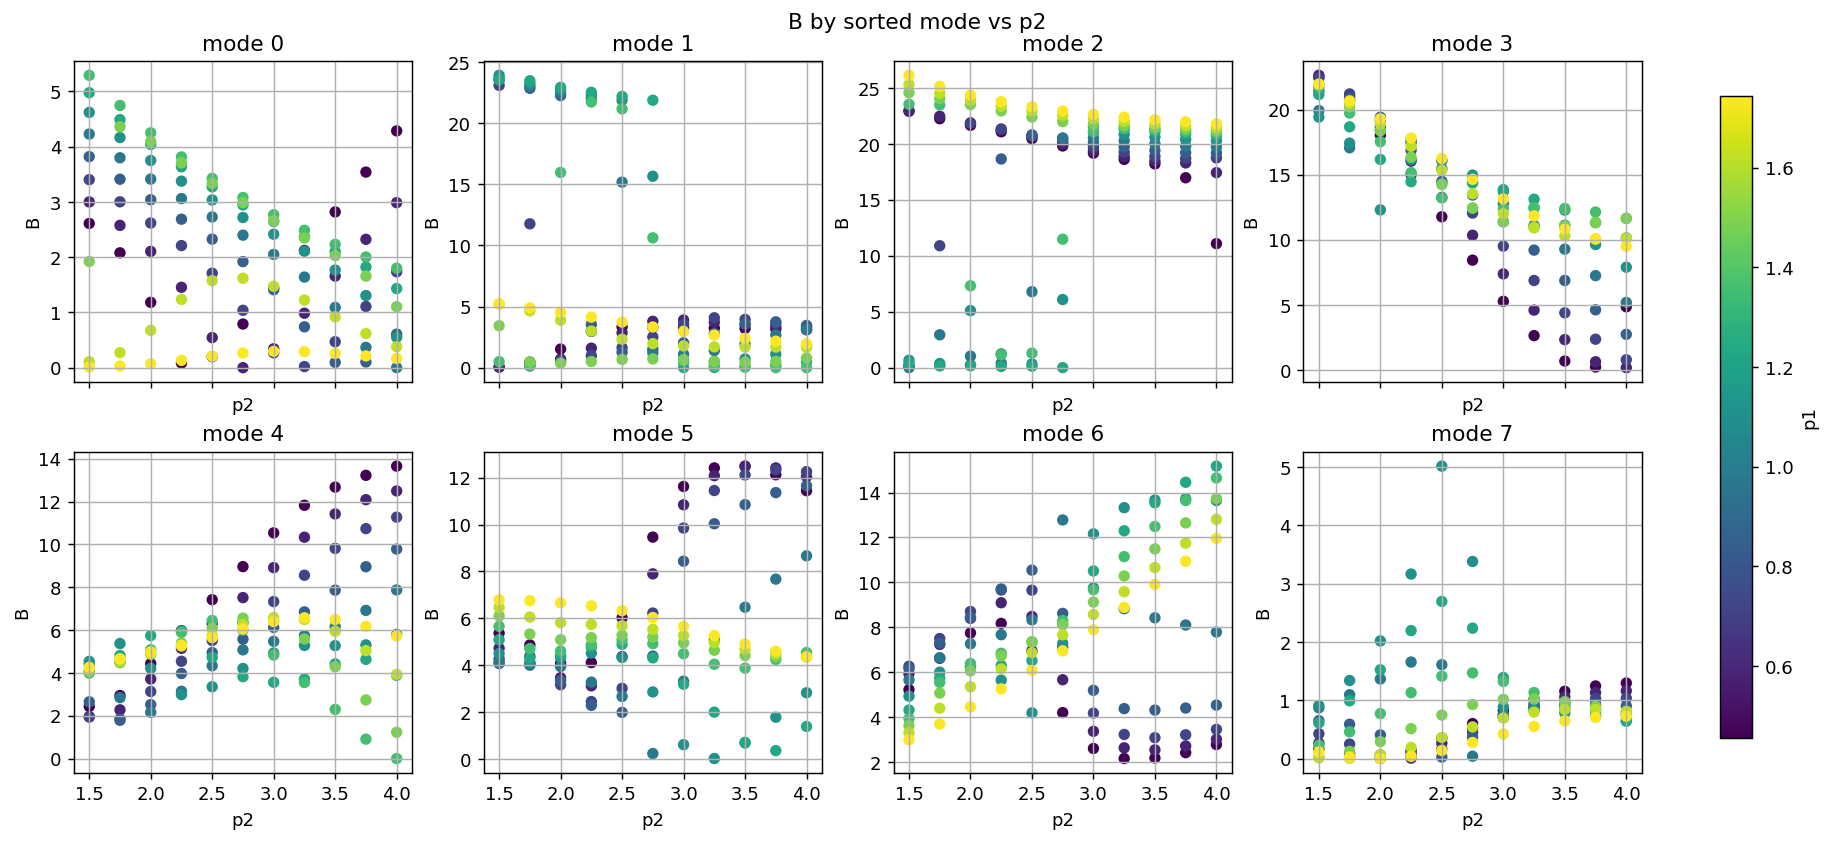

In [18]:
def plot_modes_vs_parameter(mode_df: pd.DataFrame, quantity: str, x_param: str, color_param: str):
    modes = sorted(mode_df["mode"].unique())
    fig, axes = plt.subplots(2, 4, figsize=(14, 6.2), constrained_layout=True, sharex=True)
    axes = axes.ravel()
    for ax, mode in zip(axes, modes):
        sub = mode_df[mode_df["mode"] == mode]
        sc = ax.scatter(sub[x_param], sub[quantity], c=sub[color_param], cmap="viridis", s=28)
        ax.set_title(f"mode {mode}")
        ax.set_xlabel(x_param)
        ax.set_ylabel(quantity)
    for ax in axes[len(modes):]:
        ax.axis("off")
    fig.colorbar(sc, ax=axes[: len(modes)], label=color_param, shrink=0.9)
    fig.suptitle(f"{quantity} by sorted mode vs {x_param}", y=1.02)
    plt.show()


plot_modes_vs_parameter(mode_df, "E", "p1", "p2")
plot_modes_vs_parameter(mode_df, "B", "p1", "p2")
plot_modes_vs_parameter(mode_df, "E", "p2", "p1")
plot_modes_vs_parameter(mode_df, "B", "p2", "p1")

### Combined Trajectory Views

These overlay all mode trajectories on the same axes. A branch crossing or abrupt jump is easier to see here than in the per-mode scatter plots.

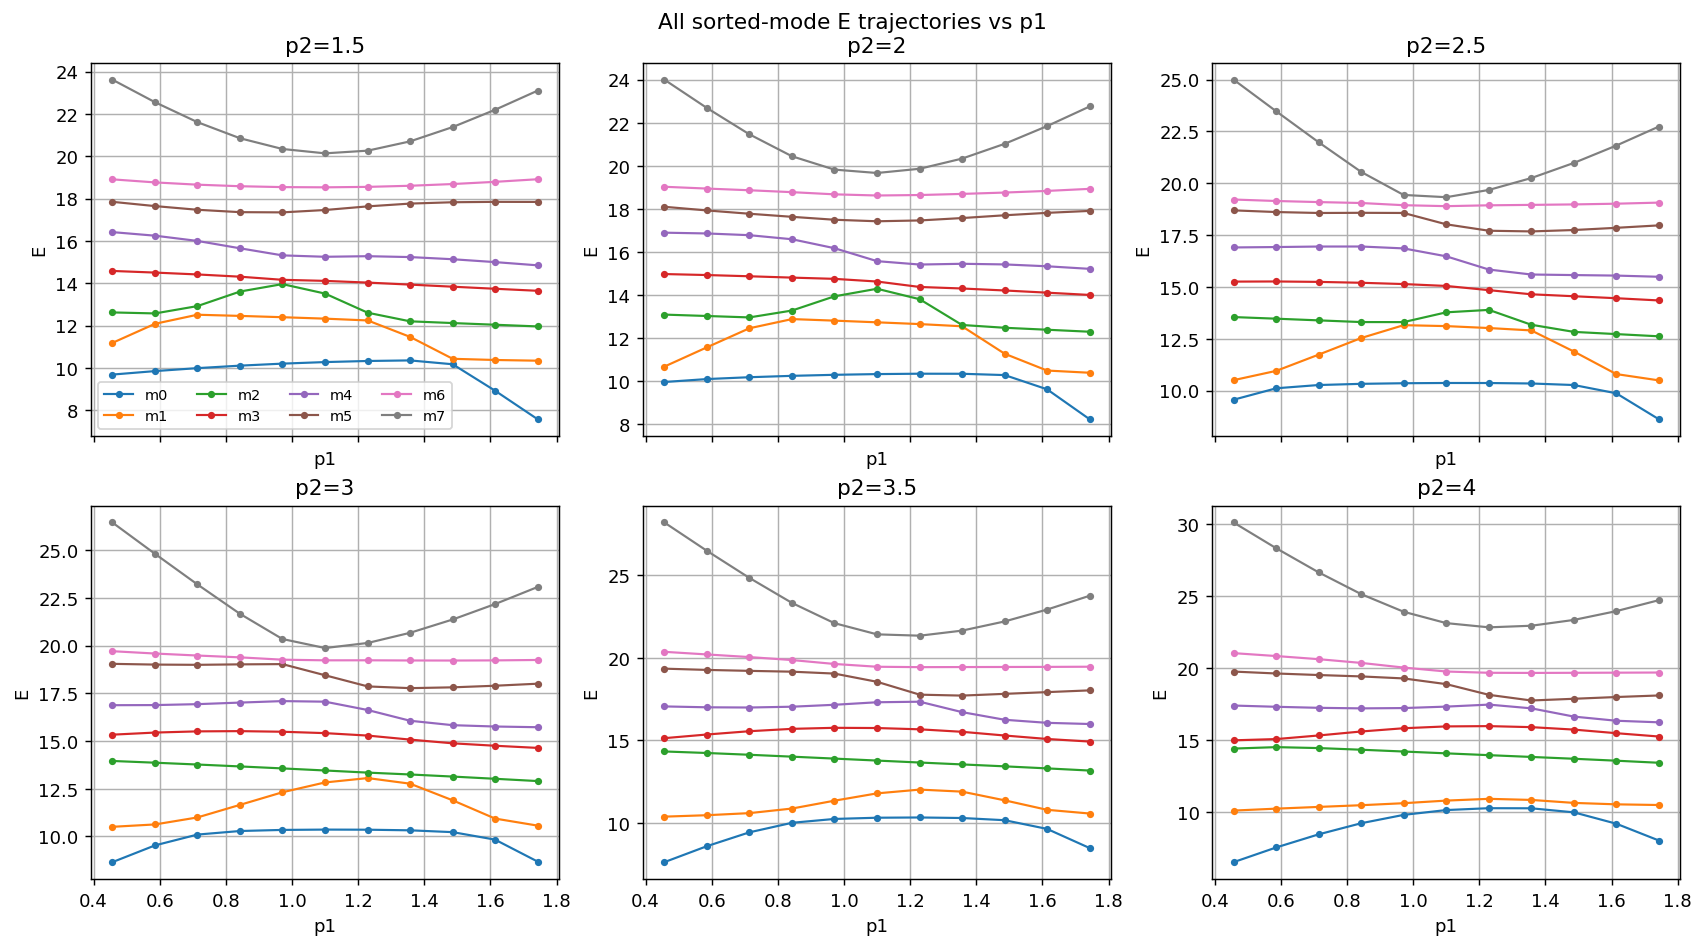

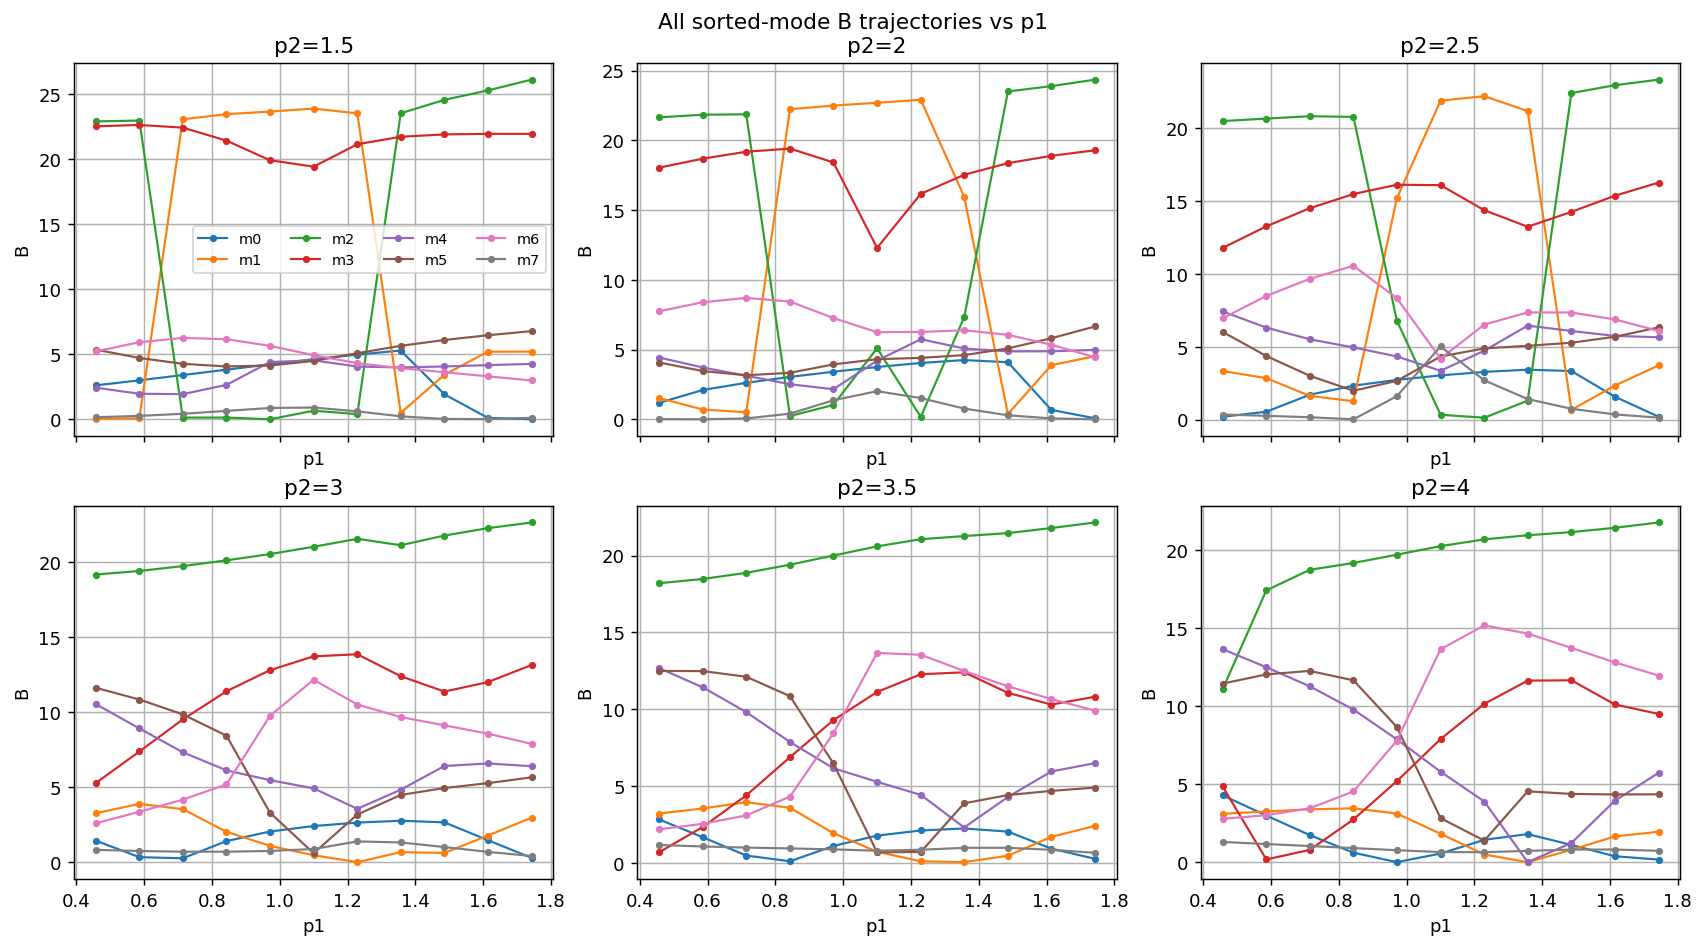

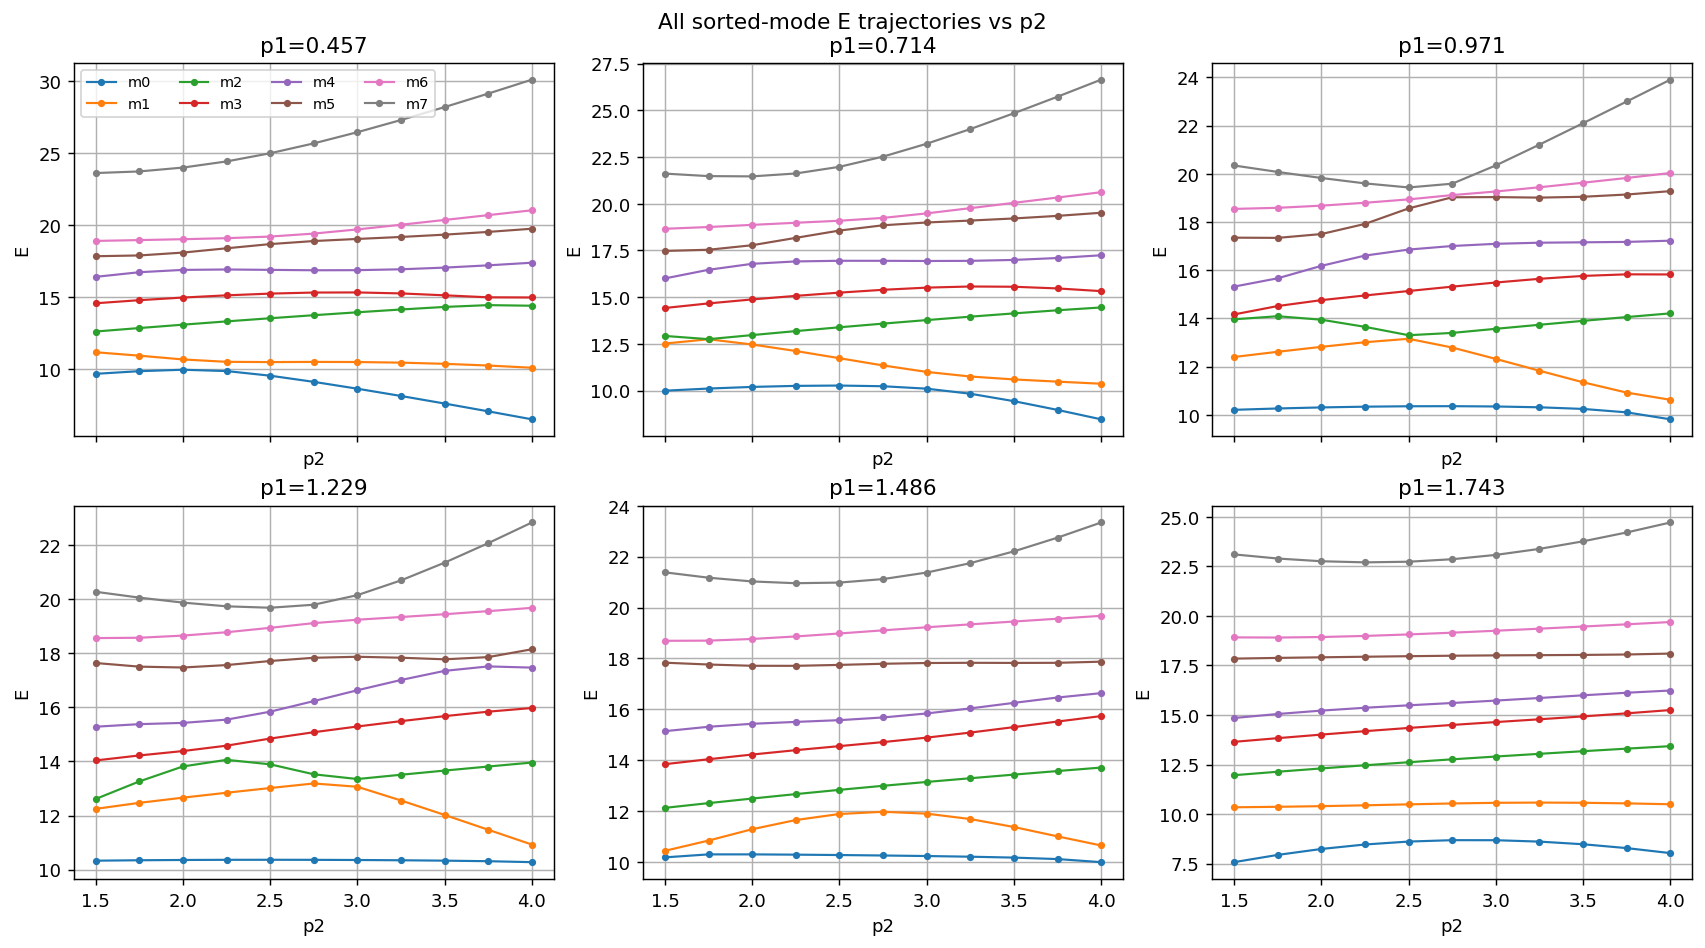

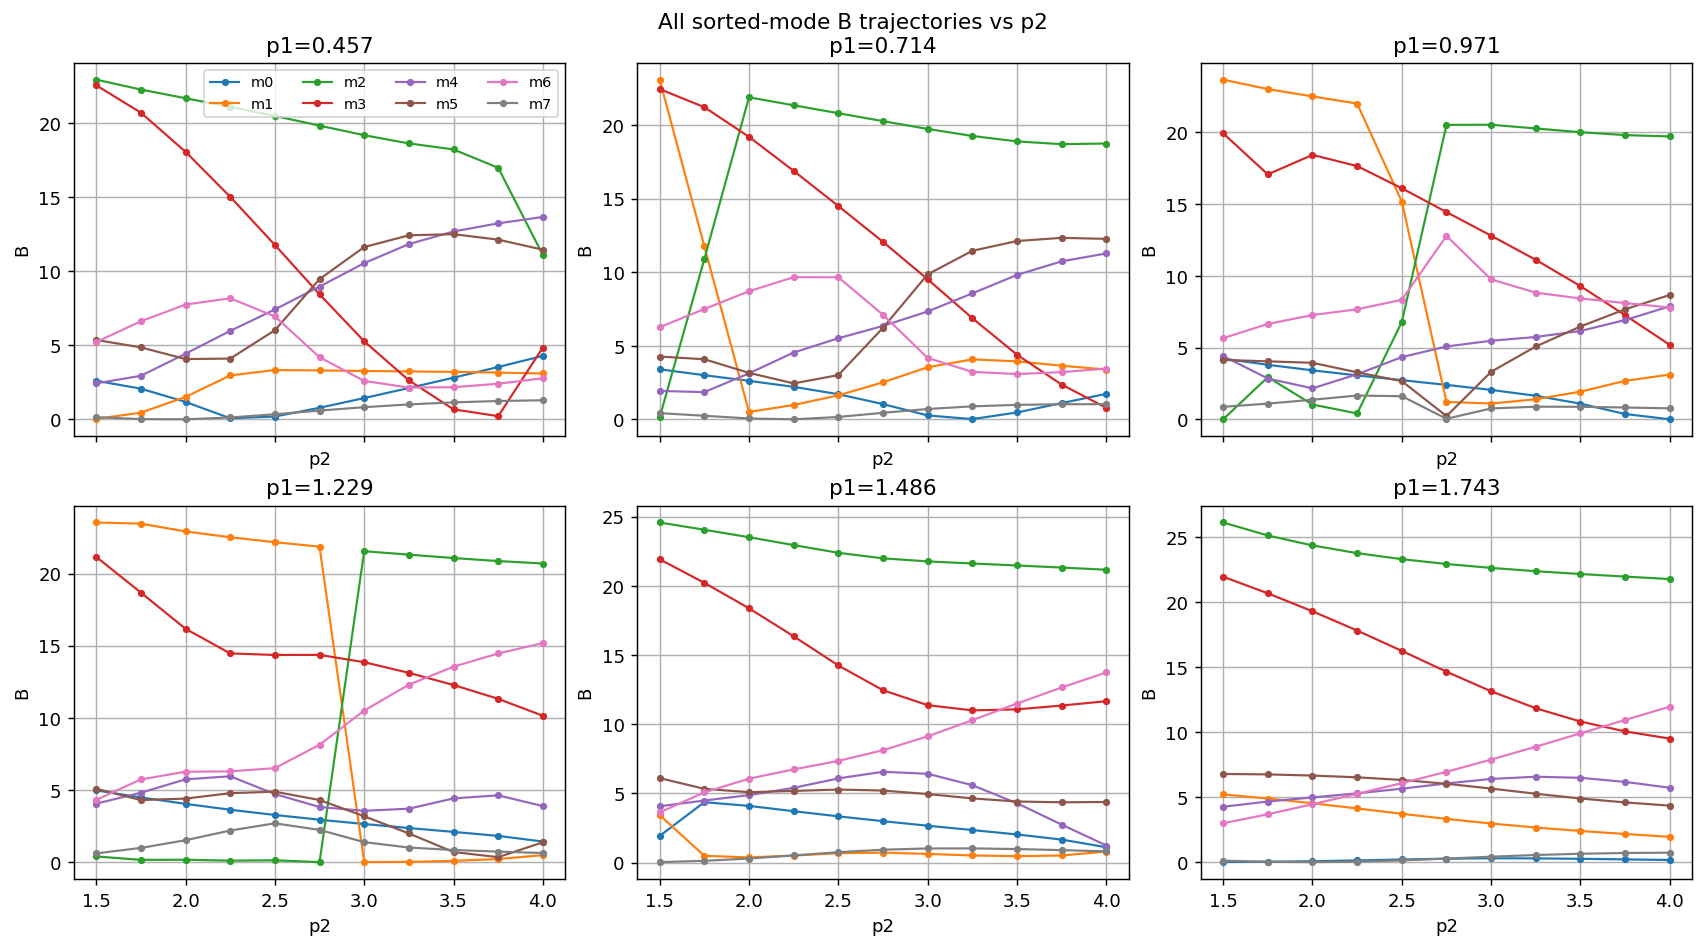

In [19]:
def representative_values(values, max_panels: int = 6):
    values = np.array(sorted(np.unique(values)), dtype=float)
    if len(values) <= max_panels:
        return values
    idx = np.linspace(0, len(values) - 1, max_panels).round().astype(int)
    return values[np.unique(idx)]


def plot_combined_trajectories(mode_df: pd.DataFrame, quantity: str, x_param: str, fixed_param: str, max_panels: int = 6):
    fixed_values = representative_values(mode_df[fixed_param], max_panels=max_panels)
    ncols = 3
    nrows = int(np.ceil(len(fixed_values) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.5 * nrows), constrained_layout=True, sharex=True)
    axes = np.atleast_1d(axes).ravel()
    cmap = plt.get_cmap("tab10")

    for ax, fixed_value in zip(axes, fixed_values):
        sub_fixed = mode_df[np.isclose(mode_df[fixed_param], fixed_value)]
        for mode in sorted(sub_fixed["mode"].unique()):
            sub = sub_fixed[sub_fixed["mode"] == mode].sort_values(x_param)
            ax.plot(sub[x_param], sub[quantity], marker="o", ms=3, lw=1.2, color=cmap(mode % 10), label=f"m{mode}")
        ax.set_title(f"{fixed_param}={fixed_value:.4g}")
        ax.set_xlabel(x_param)
        ax.set_ylabel(quantity)
    for ax in axes[len(fixed_values):]:
        ax.axis("off")
    axes[0].legend(ncol=4, fontsize=8)
    fig.suptitle(f"All sorted-mode {quantity} trajectories vs {x_param}", y=1.02)
    plt.show()


plot_combined_trajectories(mode_df, "E", x_param="p1", fixed_param="p2")
plot_combined_trajectories(mode_df, "B", x_param="p1", fixed_param="p2")
plot_combined_trajectories(mode_df, "E", x_param="p2", fixed_param="p1")
plot_combined_trajectories(mode_df, "B", x_param="p2", fixed_param="p1")